# ResNet-18 на CIFAR-10
Обучаем модель, оцениваем качество и готовим к экспорту в ONNX для Triton Inference Server.

## 1. Импорты и конфигурация

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = (
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else
    "cpu"
)

# ── Hyperparameters ───────────────────────────────────────────────────────────
EPOCHS     = 5
BATCH_SIZE = 128
LR         = 0.1

# ── Paths ─────────────────────────────────────────────────────────────────────
WEIGHTS_PATH = "outputs/best_model.pt"
ONNX_PATH    = "outputs/resnet18_cifar10.onnx"
os.makedirs("outputs", exist_ok=True)

print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device : mps
PyTorch: 2.11.0


## 2. Данные

In [2]:
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
val_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = datasets.CIFAR10("data", train=True,  download=True, transform=train_tf)
val_ds   = datasets.CIFAR10("data", train=False, download=True, transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

CLASSES = train_ds.classes
print(f"Classes : {CLASSES}")
print(f"Train   : {len(train_ds):,} samples")
print(f"Val     : {len(val_ds):,} samples")

/Users/artyem.petrov/dev/research/meetups/msu-22.04.26/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Classes : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train   : 50,000 samples
Val     : 10,000 samples


/Users/artyem.petrov/dev/research/meetups/msu-22.04.26/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


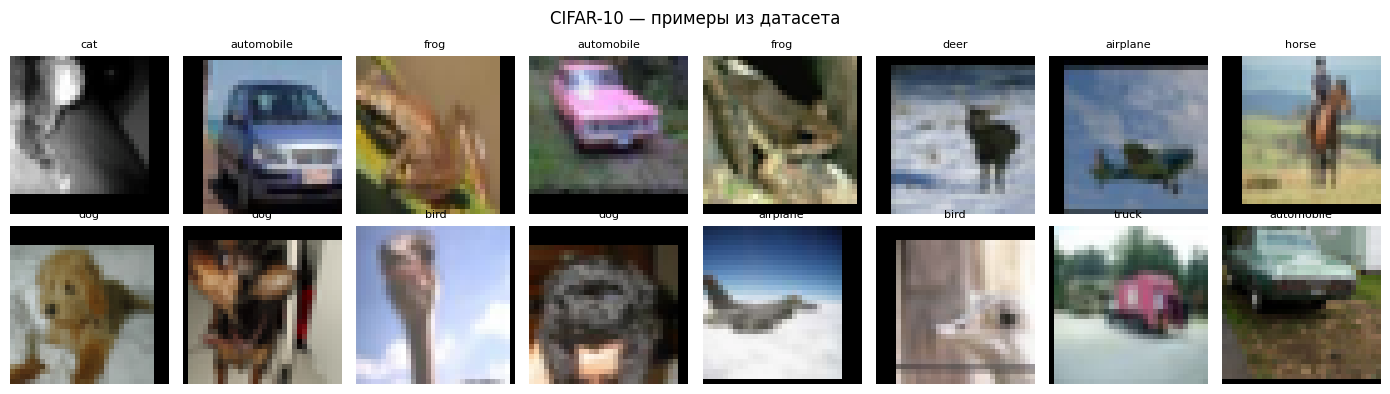

In [13]:
images, labels = next(iter(train_loader))

def denormalize(t):
    m = torch.tensor(MEAN).view(3, 1, 1)
    s = torch.tensor(STD).view(3, 1, 1)
    return (t * s + m).clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize(images[i]).cpu().permute(1, 2, 0).numpy())
    ax.set_title(CLASSES[labels[i].item()], fontsize=8)
    ax.axis("off")
plt.suptitle("CIFAR-10 — примеры из датасета", fontsize=12)
plt.tight_layout()
plt.show()

## 3. Модель

In [3]:
def build_model() -> nn.Module:
    model = models.resnet18(weights=None)
    # CIFAR-10 uses 32×32 — replace the ImageNet stem (7×7, stride 2) with a lighter one
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc      = nn.Linear(model.fc.in_features, 10)
    return model

model = build_model().to(DEVICE)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")

Total params    : 11,173,962
Trainable params: 11,173,962


## 4. Обучение

In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def run_epoch(loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for x, y in loader:
            x, y  = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss   = criterion(logits, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct    += (logits.argmax(1) == y).sum().item()
            total      += x.size(0)
    return total_loss / total, correct / total

history = None

if os.path.exists(WEIGHTS_PATH):
    print(f"Weights found at '{WEIGHTS_PATH}', skipping training.")
    model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
else:
    history  = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc = 0.0

    print(f"{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  {'Val Loss':>8}  {'Val Acc':>7}")
    print("-" * 52)

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = run_epoch(train_loader, optimizer)
        va_loss, va_acc = run_epoch(val_loader)
        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        print(f"{epoch:>5}  {tr_loss:>10.4f}  {tr_acc:>8.2%}  {va_loss:>8.4f}  {va_acc:>6.2%}")

        if va_acc > best_acc:
            best_acc = va_acc
            torch.save(model.state_dict(), WEIGHTS_PATH)

    print(f"\nBest val accuracy : {best_acc:.2%}")
    print(f"Checkpoint saved  → {WEIGHTS_PATH}")

Weights found at 'outputs/best_model.pt', skipping training.


In [5]:
if history is None:
    print("Training was skipped — no learning curves to plot.")
else:
    ep = range(1, EPOCHS + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(ep, history["train_loss"], label="Train")
    ax1.plot(ep, history["val_loss"],   label="Val")
    ax1.set(title="Loss", xlabel="Epoch")
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(ep, [a * 100 for a in history["train_acc"]], label="Train")
    ax2.plot(ep, [a * 100 for a in history["val_acc"]],   label="Val")
    ax2.set(title="Accuracy (%)", xlabel="Epoch")
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle("Learning Curves — ResNet-18 / CIFAR-10", fontsize=13)
    plt.tight_layout()
    plt.show()

Training was skipped — no learning curves to plot.


## 5. Оценка качества

In [6]:
model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in val_loader:
        preds = model(x.to(DEVICE)).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(y)

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

overall_acc = (all_preds == all_labels).float().mean().item()
print(f"Overall accuracy: {overall_acc:.2%}\n")

print(f"{'Class':>12}  {'Acc':>6}")
print("-" * 22)
for i, cls in enumerate(CLASSES):
    mask = all_labels == i
    acc  = (all_preds[mask] == all_labels[mask]).float().mean().item()
    print(f"{cls:>12}  {acc:>5.1%}")

/Users/artyem.petrov/dev/research/meetups/msu-22.04.26/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Overall accuracy: 76.40%

       Class     Acc
----------------------
    airplane  82.8%
  automobile  92.0%
        bird  81.8%
         cat  43.3%
        deer  64.2%
         dog  71.5%
        frog  78.5%
       horse  79.6%
        ship  84.9%
       truck  85.4%


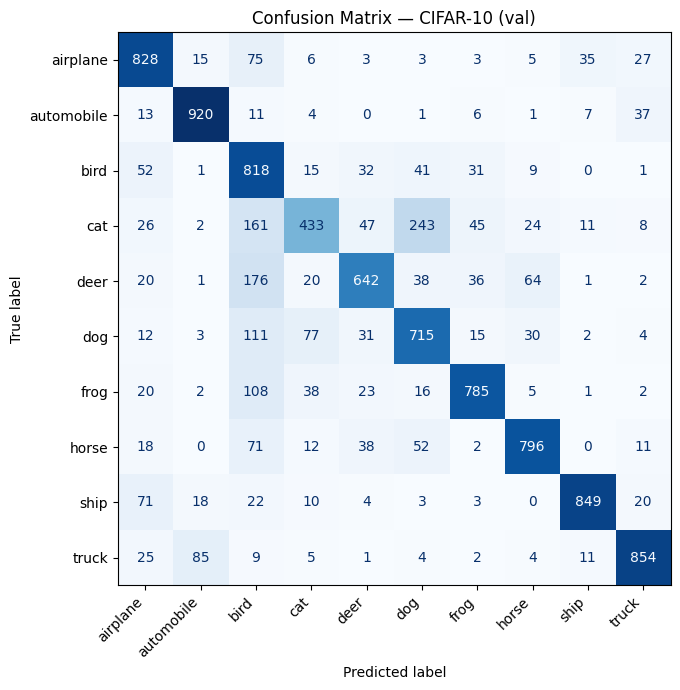

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(all_labels.numpy(), all_preds.numpy())

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, colorbar=False, cmap="Blues")
plt.title("Confusion Matrix — CIFAR-10 (val)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

/Users/artyem.petrov/dev/research/meetups/msu-22.04.26/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


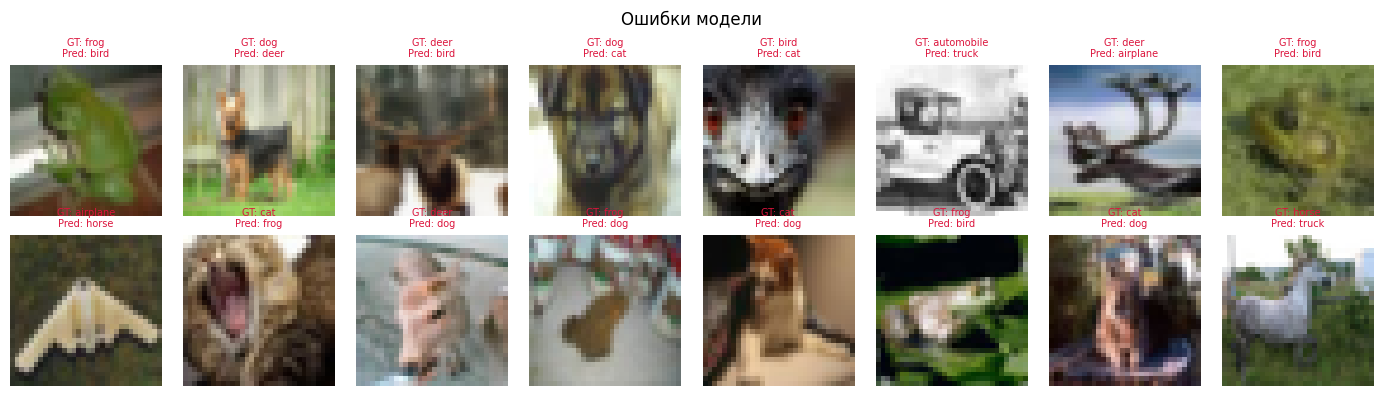

In [8]:
wrong_idx = (all_preds != all_labels).nonzero(as_tuple=True)[0]
raw_val   = datasets.CIFAR10("data", train=False, download=False, transform=transforms.ToTensor())

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for ax, idx in zip(axes.flat, wrong_idx[:16]):
    img, _ = raw_val[idx]
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(
        f"GT: {CLASSES[all_labels[idx]]}\nPred: {CLASSES[all_preds[idx]]}",
        fontsize=7, color="crimson",
    )
    ax.axis("off")
plt.suptitle("Ошибки модели", fontsize=12)
plt.tight_layout()
plt.show()

## 6. Подготовка к экспорту в ONNX

In [9]:
import onnx
import onnxruntime as ort

model.eval()
dummy = torch.randn(1, 3, 32, 32)

torch.onnx.export(
    model.cpu(), dummy, ONNX_PATH,
    input_names=["image"],
    output_names=["logits"],
    dynamic_axes={"image": {0: "batch_size"}, "logits": {0: "batch_size"}},
    opset_version=17,
)

# Triton / MLServer ship with onnxruntime ≤1.15 which supports IR ≤9
proto = onnx.load(ONNX_PATH)
proto.ir_version = 8
onnx.save(proto, ONNX_PATH)

print(f"Exported    → {ONNX_PATH}")
print(f"IR version  → {proto.ir_version}")

onnx.checker.check_model(onnx.load(ONNX_PATH))
print("ONNX check  passed")

session = ort.InferenceSession(ONNX_PATH, providers=["CPUExecutionProvider"])
ort_out = session.run(None, {"image": dummy.numpy()})[0]

with torch.no_grad():
    pt_out = model.cpu()(dummy).numpy()

max_diff = np.abs(pt_out - ort_out).max()
print(f"Max diff    {max_diff:.2e}  (PyTorch vs ONNX Runtime)")
assert max_diff < 1e-4, "Outputs diverge!"
print("\nМодель готова к деплою в Triton Inference Server")

/var/folders/ym/22fx55fn2txc2hplzs04sfsm0000gp/T/ipykernel_5491/140964652.py:7: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0422 10:49:15.503000 5491 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/opt/homebrew/Cellar/python@3.12/3.12.13/Frameworks/Python.framework/Versions/3.12/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).
Failed to convert the model to the target version 17 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/Users/artyem.petrov/dev/research/meetups/msu-22.04.26/.venv/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/artyem.petrov/dev/research/meetups/msu-22.04.26/.venv/lib/python3.12/site-packages/onnxscript/version_converter/_c_api_utils.py", lin

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported    → outputs/resnet18_cifar10.onnx
IR version  → 8
ONNX check  passed
Max diff    1.19e-06  (PyTorch vs ONNX Runtime)

Модель готова к деплою в Triton Inference Server
